# Softmax exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](https://compsci682-fa19.github.io/assignments2019/assignment1/) on the course website.*

This exercise is analogous to the SVM exercise. You will:

- implement a fully-vectorized **loss function** for the Softmax classifier
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** with numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [ ]:
### IF YOU ARE USING COLAB, UNCOMMENT AND RUN THIS BLOCK FIRST ###

# # Mount google drive to allow access to your files
# from google.colab import drive
# drive.mount('/content/drive')
# drive_folder = '/content/drive/MyDrive'
# # Ajust this line to be the assignment1 folder in your google drive
# notebook_folder = drive_folder + '/cs682/assignment1'
# %cd {notebook_folder}

In [2]:
from __future__ import print_function
import random
import numpy as np
from cs682.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the linear classifier. These are the same steps as we used for the
    SVM, but condensed to a single function.
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs682/datasets/cifar-10-batches-py'
    # Don't forget to run get_datasets.sh, or this will throw an error
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]

    # Preprocessing: reshape the image data into rows
    X_train = np.reshape(X_train, (X_train.shape[0], -1))
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image

    # add bias dimension and transform into columns
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev


# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('dev data shape: ', X_dev.shape)
print('dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3073)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3073)
Test labels shape:  (1000,)
dev data shape:  (500, 3073)
dev labels shape:  (500,)


## Softmax Classifier

Your code for this section will all be written inside **cs682/classifiers/softmax.py**.


In [5]:
# First implement the naive softmax loss function with nested loops.
# Open the file cs682/classifiers/softmax.py and implement the
# softmax_loss_naive function.

from cs682.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 0.000000
sanity check: 2.302585


## Inline Question 1:
Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

**Your answer:**  
In the CIFAR-10 dataset, we have 10 classes. Since the sum of all probabilites should be equal to 1, that means on an average, the probability of each class should be 0.1. In the initial stages, the weights are initialized randomly, so the probability of each class should be close to 0.1. Since the loss is predicted as 
$$
Loss = -log(predicted\;probability\;of\;correct\;class)
$$
and the predicted probability of the correct class is 0.1, the loss should be close to 
$-log(0.1)\;\approx\;2.302$.


In [7]:
# Complete the implementation of softmax_loss_naive and implement a (naive)
# version of the gradient that uses nested loops.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As we did for the SVM, use numeric gradient checking as a debugging tool.
# The numeric gradient should be close to the analytic gradient.
from cs682.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

# similar to SVM case, do another gradient check with regularization
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -2.341302 analytic: -2.341302, relative error: 6.137100e-09
numerical: -1.308894 analytic: -1.308894, relative error: 2.140041e-08
numerical: 2.568393 analytic: 2.568393, relative error: 1.928575e-08
numerical: 2.691410 analytic: 2.691410, relative error: 1.516870e-08
numerical: 1.094773 analytic: 1.094773, relative error: 8.633188e-08
numerical: -5.486569 analytic: -5.486569, relative error: 3.222933e-09
numerical: 0.122295 analytic: 0.122295, relative error: 6.907702e-08
numerical: 0.039443 analytic: 0.039443, relative error: 2.174636e-08
numerical: 2.882194 analytic: 2.882194, relative error: 1.624776e-08
numerical: -0.338670 analytic: -0.338670, relative error: 1.819153e-07
numerical: 0.582381 analytic: 0.582381, relative error: 9.515961e-08
numerical: 1.036775 analytic: 1.036775, relative error: 2.396556e-08
numerical: -2.384527 analytic: -2.384527, relative error: 1.307640e-08
numerical: 5.534999 analytic: 5.534999, relative error: 3.880433e-09
numerical: 0.331627 anal

In [8]:
# Now that we have a naive implementation of the softmax loss function and its gradient,
# implement a vectorized version in softmax_loss_vectorized.
# The two versions should compute the same results, but the vectorized version should be
# much faster.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs682.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# As we did for the SVM, we use the Frobenius norm to compare the two versions
# of the gradient.
grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.378456e+00 computed in 0.043008s
vectorized loss: 2.378456e+00 computed in 0.008241s
Loss difference: 0.000000
Gradient difference: 0.000000


In [10]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of over 0.35 on the validation set.
from cs682.classifiers import Softmax
results = {}
best_val = -1
best_softmax = None

# Borrowing the code from the SVM notebook to perform hyperparameter tuning
learning_rates = np.geomspace(2e-7, 3e-7, 5)
regularization_strengths = np.geomspace(5e3, 5e4, 5)

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the SVM; save    #
# the best trained softmax classifer in best_softmax.                          #
################################################################################
# Your code

# Note To Self:
# Use itertools.product to generate all possible combinations of learning_rates and regularization_strengths
# This will generate a list of tuples, where each tuple is a combination of learning_rate and regularization_strength and will let us iterate over all possible combinations (as a nested loop)

import itertools
for learning_rate, reg_strength in itertools.product(learning_rates, regularization_strengths):
    softmax = Softmax()
    softmax.train(X_train, y_train, learning_rate=learning_rate, reg=reg_strength, num_iters=1500, verbose=False)
    
    y_train_pred = softmax.predict(X_train)
    y_val_pred = softmax.predict(X_val)
    
    train_accuracy = np.mean(y_train == y_train_pred)
    val_accuracy = np.mean(y_val == y_val_pred)
    
    results[(learning_rate, reg_strength)] = (train_accuracy, val_accuracy)
    
    if val_accuracy > best_val:
        best_val = val_accuracy
        best_softmax = softmax

################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 2.000000e-07 reg 5.000000e+03 train accuracy: 0.370755 val accuracy: 0.382000
lr 2.000000e-07 reg 8.891397e+03 train accuracy: 0.360531 val accuracy: 0.370000
lr 2.000000e-07 reg 1.581139e+04 train accuracy: 0.345735 val accuracy: 0.357000
lr 2.000000e-07 reg 2.811707e+04 train accuracy: 0.324347 val accuracy: 0.335000
lr 2.000000e-07 reg 5.000000e+04 train accuracy: 0.307510 val accuracy: 0.323000
lr 2.213364e-07 reg 5.000000e+03 train accuracy: 0.372265 val accuracy: 0.397000
lr 2.213364e-07 reg 8.891397e+03 train accuracy: 0.361469 val accuracy: 0.379000
lr 2.213364e-07 reg 1.581139e+04 train accuracy: 0.346816 val accuracy: 0.354000
lr 2.213364e-07 reg 2.811707e+04 train accuracy: 0.325327 val accuracy: 0.343000
lr 2.213364e-07 reg 5.000000e+04 train accuracy: 0.306939 val accuracy: 0.320000
lr 2.449490e-07 reg 5.000000e+03 train accuracy: 0.370980 val accuracy: 0.386000
lr 2.449490e-07 reg 8.891397e+03 train accuracy: 0.362531 val accuracy: 0.377000
lr 2.449490e-07 reg 1.581139

In [11]:
# evaluate on test set
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

softmax on raw pixels final test set accuracy: 0.361000


**Inline Question** - *True or False*

It's possible to add a new datapoint to a training set that would leave the SVM loss unchanged, but this is not the case with the Softmax classifier loss.

*Your answer*: **True**

*Your explanation*:  
In an SVM, the loss depends on the margin between the correct class and the other classes. If the margin is greater than the margin threshold, the loss is 0. Thus the overall loss is unchanged. (If the new datapoint is correctly classified and lies outside the margin)  
In a Softmax classifier, every data point contributes to the loss. The loss is based on probabilities, even of the correct class and adding a new data point will change the probabilities and hence the loss. Thus is it not possible to add a new data point without changing the loss in a Softmax classifier, even if the new data point is correctly classified.

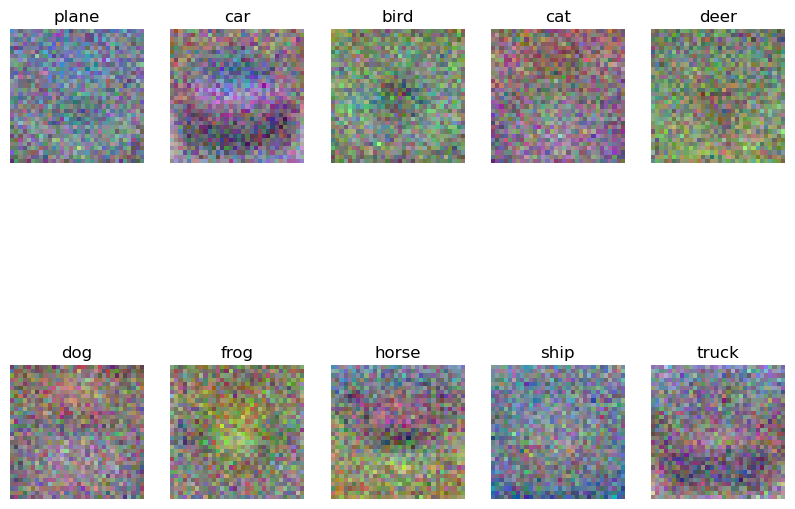

In [12]:
# Visualize the learned weights for each class
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])